In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, CategoricalNB
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, recall_score, precision_recall_curve,
    roc_auc_score, average_precision_score, cohen_kappa_score, PrecisionRecallDisplay
)
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.pipeline import Pipeline as ImbPipeline

## Data Preparation

In [6]:
# =====================
# 1. Prepare Data
# =====================

# Define features
continuous_features = ['child weight']
categorical_features = [
    'child age',
    'diarrhoea',
    'fever',
    'area',
    'child sex',
    'mother education',
    'health insurance',
    'wealth index',
    'gandaki',
    'karnali',
    'koshi',
    'madhesh',
    'lumbini',
    'sudurpashchim'
]

# Load data
df = pd.read_csv(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.csv") #Local

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

# print("Before SMOTE:", Counter(y_train))
# print("After SMOTE:", Counter(y_train_sm))

X_train_cat_sm = X_train_sm[categorical_features]
X_train_cont_sm = X_train_sm[continuous_features]

X_test_cat = X_test[categorical_features]
X_test_cont = X_test[continuous_features]


## Base Model

In [7]:
# ===================
# 2. Base Decision Tree Model (SMOTE outside pipeline)
# ===================

cat_nb = CategoricalNB()  # default smoothing
cont_nb = GaussianNB()  # default

cat_nb.fit(X_train_cat_sm, y_train_sm)
cont_nb.fit(X_train_cont_sm, y_train_sm)

log_prob_cat = cat_nb.predict_log_proba(X_test_cat)
log_prob_cont = cont_nb.predict_log_proba(X_test_cont)

combined_log_proba = log_prob_cat + log_prob_cont
combined_proba = np.exp(combined_log_proba)
combined_proba /= combined_proba.sum(axis=1, keepdims=True)

y_pred_base = np.argmax(combined_proba, axis=1)
y_proba_base = combined_proba[:, 1]

# Evaluation
print(confusion_matrix(y_test, y_pred_base))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_base, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_base):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_base):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_base):.3f}")
# Recall on training set
log_prob_cat_train = cat_nb.predict_log_proba(X_train_cat_sm)
log_prob_cont_train = cont_nb.predict_log_proba(X_train_cont_sm)
combined_log_proba_train = log_prob_cat_train + log_prob_cont_train
combined_proba_train = np.exp(combined_log_proba_train)
combined_proba_train /= combined_proba_train.sum(axis=1, keepdims=True)
y_train_pred_base = np.argmax(combined_proba_train, axis=1)
# Training recall
print(f"Training recall: {recall_score(y_train_sm, y_train_pred_base):.3f}")


[[411 296]
 [203 401]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.669     0.581     0.622       707
           1      0.575     0.664     0.616       604

    accuracy                          0.619      1311
   macro avg      0.622     0.623     0.619      1311
weighted avg      0.626     0.619     0.620      1311

------------------------------------------------------
Test Avg Precision: 0.633
Test AUC: 0.672
Test Cohen's Kappa: 0.243
Training recall: 0.668


## Tuned Model

In [10]:
# ====================
# 2. Tuned Model: SMOTE inside pipeline with GridSearchCV
# ====================

class MixedNBWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, alpha_cat=1.0, var_smoothing=1e-9):
        self.alpha_cat = alpha_cat
        self.var_smoothing = var_smoothing
        self.cat_nb = CategoricalNB(alpha=self.alpha_cat)
        self.cont_nb = GaussianNB(var_smoothing=self.var_smoothing)

    def fit(self, X, y):
        X_cat = X[categorical_features]
        X_cont = X[continuous_features]
        self.cat_nb = CategoricalNB(alpha=self.alpha_cat)
        self.cont_nb = GaussianNB(var_smoothing=self.var_smoothing)
        self.cat_nb.fit(X_cat, y)
        self.cont_nb.fit(X_cont, y)
        return self

    def predict_proba(self, X):
        X_cat = X[categorical_features]
        X_cont = X[continuous_features]
        log_prob_cat = self.cat_nb.predict_log_proba(X_cat)
        log_prob_cont = self.cont_nb.predict_log_proba(X_cont)
        combined_log_prob = log_prob_cat + log_prob_cont
        combined_prob = np.exp(combined_log_prob)
        combined_prob /= combined_prob.sum(axis=1, keepdims=True)
        return combined_prob

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def get_params(self, deep=True):
        return {
            'alpha_cat': self.alpha_cat,
            'var_smoothing': self.var_smoothing
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self



pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('mixed_nb', MixedNBWrapper())
])

param_grid = {
    'mixed_nb__alpha_cat': [0.1, 0.2, 0.5, 1.0],
    'mixed_nb__var_smoothing': [1e-9, 1e-8, 1e-7]
}

grid_search = GridSearchCV(
    pipe,
    param_grid=param_grid,
    scoring='recall',
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42),
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

best_mixed_nb = grid_search.best_estimator_
y_pred_tune = best_mixed_nb.predict(X_test)
y_proba_tune = best_mixed_nb.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid_search.best_params_)
print('------------------------------------------------------')
print(confusion_matrix(y_test, y_pred_tune))
print('------------------------------------------------------')
print(classification_report(y_test, y_pred_tune, digits=3))
print('------------------------------------------------------')
print(f"Test Avg Precision: {average_precision_score(y_test, y_proba_tune):.3f}")
print(f"Test AUC: {roc_auc_score(y_test, y_proba_tune):.3f}")
print(f"Test Cohen's Kappa: {cohen_kappa_score(y_test, y_pred_tune):.3f}")
# Recall on training set
y_train_pred_tuned = best_mixed_nb.predict(X_train) # SMOTE is handled inside pipe
y_train_proba_tuned = best_mixed_nb.predict_proba(X_train)[:, 1]
print(f"Training Recall: {recall_score(y_train, y_train_pred_tuned):.3f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best Parameters: {'mixed_nb__alpha_cat': 0.1, 'mixed_nb__var_smoothing': 1e-09}
------------------------------------------------------
[[411 296]
 [203 401]]
------------------------------------------------------
              precision    recall  f1-score   support

           0      0.669     0.581     0.622       707
           1      0.575     0.664     0.616       604

    accuracy                          0.619      1311
   macro avg      0.622     0.623     0.619      1311
weighted avg      0.626     0.619     0.620      1311

------------------------------------------------------
Test Avg Precision: 0.633
Test AUC: 0.672
Test Cohen's Kappa: 0.243
Training Recall: 0.664


c:\Users\dbastola2022\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_search.py:979: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


### 95% CI on Recall

Recall 95% CI: (0.625, 0.703)


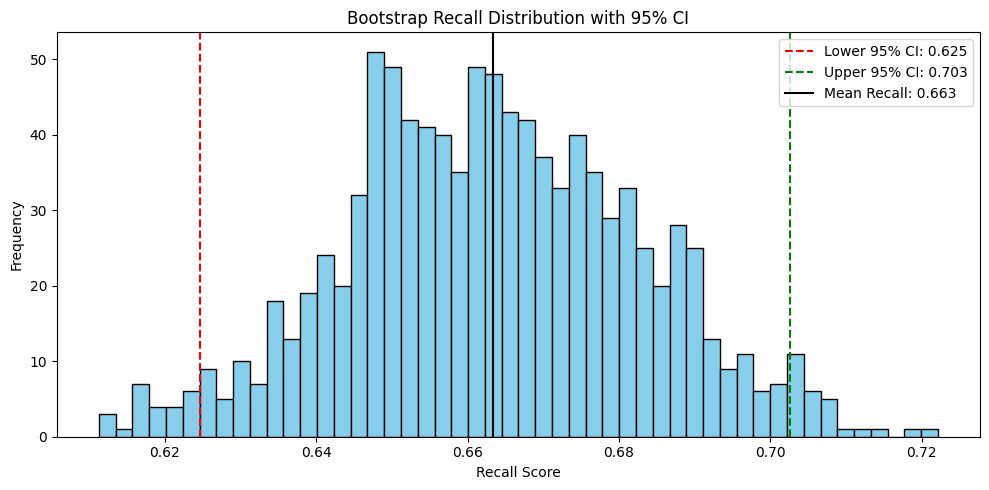

In [11]:
# Bootstrap
def bootstrap_ci_recall_distribution(y_true, y_pred_func, X, n_bootstraps=1000, alpha=0.95):
    rng = np.random.RandomState(42)
    bootstrapped_scores = []
    n = len(y_true)
    for _ in range(n_bootstraps):
        indices = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true.iloc[indices])) < 2:
            continue
        score = recall_score(y_true.iloc[indices], y_pred_func(X.iloc[indices]))
        bootstrapped_scores.append(score)
    sorted_scores = np.sort(bootstrapped_scores)
    lower = np.percentile(sorted_scores, ((1-alpha)/2)*100)
    upper = np.percentile(sorted_scores, (alpha + (1-alpha)/2)*100)
    return bootstrapped_scores, lower, upper

# scores
recall_scores, lower_ci, upper_ci = bootstrap_ci_recall_distribution(
    y_test.reset_index(drop=True), 
    best_mixed_nb.predict, 
    X_test.reset_index(drop=True)
)

print(f"Recall 95% CI: ({lower_ci:.3f}, {upper_ci:.3f})")

# plot
plt.figure(figsize=(10, 5))
plt.hist(recall_scores, bins=50, color='skyblue', edgecolor='black')
plt.axvline(lower_ci, color='red', linestyle='--', label=f"Lower 95% CI: {lower_ci:.3f}")
plt.axvline(upper_ci, color='green', linestyle='--', label=f"Upper 95% CI: {upper_ci:.3f}")
plt.axvline(np.mean(recall_scores), color='black', linestyle='-', label=f"Mean Recall: {np.mean(recall_scores):.3f}")
plt.title("Bootstrap Recall Distribution with 95% CI")
plt.xlabel("Recall Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### Average Precision Plot

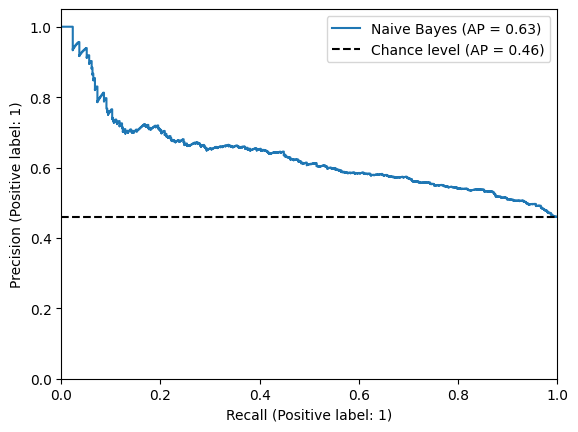

In [12]:
# Predict probabilities for positive class
y_proba = best_mixed_nb.predict_proba(X_test)[:, 1]

display = PrecisionRecallDisplay.from_predictions(
    y_test,      # True labels
    y_proba,     # Predicted scores/probabilities
    name="Naive Bayes",
    plot_chance_level=True
)

# display.ax_.set_title("Naive Bayes Precision-Recall curve")
display.ax_.legend(loc='upper right')
display.ax_.set_xlim([0.0, 1.0])
display.ax_.set_ylim([0.0, 1.05])
plt.show()


## Additional

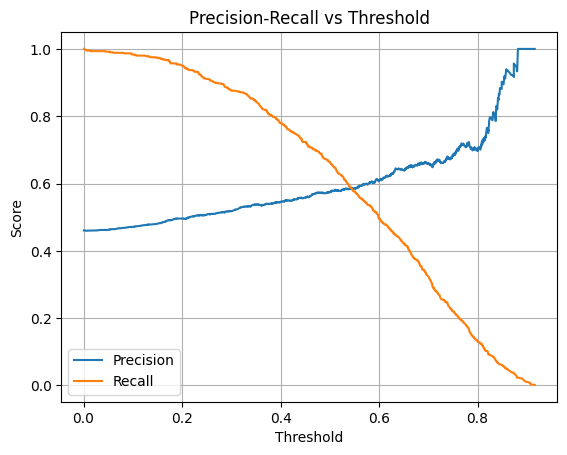

In [13]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_tune)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.grid()
plt.legend()
plt.show()

In [14]:
# Apply custom threshold
y_proba_custom = (y_proba_tune >= 0.40).astype(int)
print(f'Classification Report: \n{classification_report(y_test, y_proba_custom)}\n')

Classification Report: 
              precision    recall  f1-score   support

           0       0.70      0.45      0.55       707
           1       0.55      0.78      0.64       604

    accuracy                           0.60      1311
   macro avg       0.62      0.61      0.59      1311
weighted avg       0.63      0.60      0.59      1311


